The tutorial is partially based on "Introduction to PyTorch Library" tutorial created by NCC Türkiye in the frame of EuroCC2 programme.

https://indico.truba.gov.tr/event/157

# Introduction to PyTorch Tensors

A **tensor** is the central data structure in PyTorch — a multi-dimensional array similar to NumPy's `ndarray`, but with **GPU acceleration** and **automatic differentiation** support.

This notebook covers the essentials: creating tensors, arithmetic, indexing, broadcasting, shape manipulation, masking, and NumPy interop.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

from tensor_viz import (
    plot_sin_cos, plot_dot_product, plot_cross_product, plot_matmul,
    plot_broadcasting, plot_slicing, plot_reshape, plot_masking, plot_relu,
    plot_tensors,
)

print(f"PyTorch version: {torch.__version__}")

ModuleNotFoundError: No module named 'torch'

---
## 1. Creating and Initialising Tensors

The simplest way to create a tensor is with `torch.tensor()` — it creates a copy of your Python list or tuple data.

Key tensor properties:
- **shape**: dimensions of the tensor (rows × columns for 2D)
- **dtype**: data type (int64, float32, etc.)
- **ndim**: number of dimensions
- **numel**: total number of elements

Tensor shape=torch.Size([2, 3])  dtype=torch.int64  ndim=2  numel=6


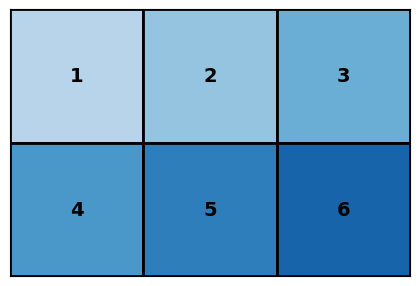

In [2]:
# From Python data
a = torch.tensor([[1, 2, 3],
                   [4, 5, 6]])
print(f"Tensor shape={a.shape}  dtype={a.dtype}  ndim={a.ndim}  numel={a.numel()}")
plot_tensors((a, ""))

### Factory Functions

Rather than initializing from Python data, you'll often create tensors with factory methods:
- `zeros()` / `ones()` — fill with 0s or 1s
- `full()` — fill with a specific value
- `rand()` — uniform random in [0, 1)
- `randn()` — standard normal distribution (mean=0, std=1)
- `randint()` — random integers in a range
- `arange()` — like Python's `range()`, but returns a tensor
- `linspace()` — evenly spaced values between start and end

In [3]:
# Common factory functions
zeros  = torch.zeros(2, 3)
ones   = torch.ones(2, 3)
full   = torch.full((2, 3), 3.14)
rng    = torch.rand(2, 3)          # uniform [0, 1)
normal = torch.randn(2, 3)         # standard normal
ints   = torch.randint(0, 10, (2, 3))
seq    = torch.arange(0, 10, 2)    # [0, 2, 4, 6, 8]
lin    = torch.linspace(0, 1, 5)   # 5 evenly-spaced points

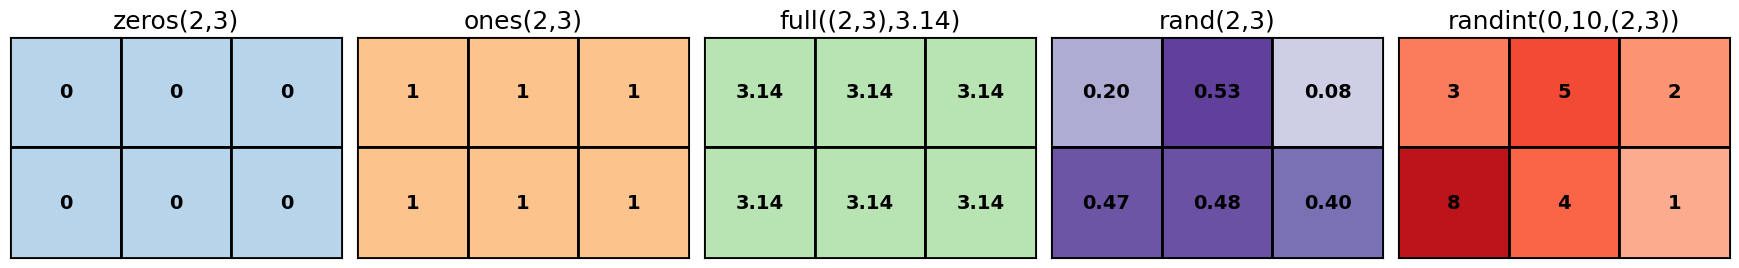

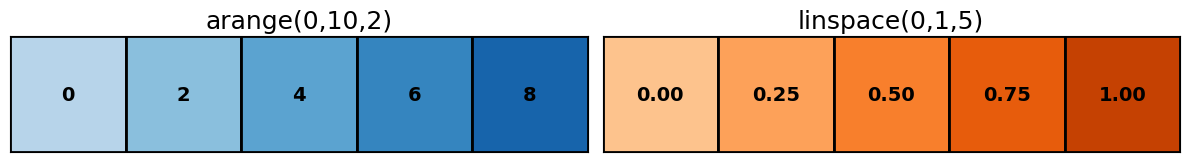

In [4]:
plot_tensors((zeros, "zeros(2,3)"), (ones, "ones(2,3)"),
             (full, "full((2,3),3.14)"), (rng, "rand(2,3)"),
             (ints, "randint(0,10,(2,3))"))
plot_tensors((seq, "arange(0,10,2)"), (lin, "linspace(0,1,5)"))

### Like Functions

The `*_like()` factory functions are useful when you need to create a tensor with the **same shape, dtype, and device** as an existing tensor. This is especially helpful when you need tensors that match your input dimensions but with different values (e.g., masks, placeholders).

In [5]:
# *_like functions: create a tensor with the same shape/dtype/device as another
x = torch.rand(2, 4)
x_zeros = torch.zeros_like(x)
x_ones = torch.ones_like(x)

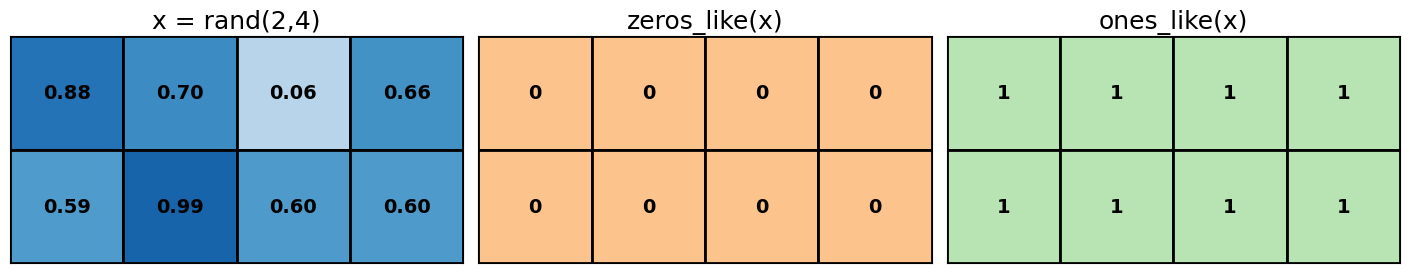

In [6]:
plot_tensors((x, "x = rand(2,4)"),
             (x_zeros, "zeros_like(x)"),
             (x_ones, "ones_like(x)"))

### Reproducibility with manual seed

When you call `torch.manual_seed()`, the next random operations will always produce the same sequence of values. This is important for:
- Debugging (consistent behavior across runs)
- Research (reproducible experiments)
- Testing (deterministic outputs)

See [PyTorch reproducibility docs](https://pytorch.org/docs/stable/notes/randomness.html) for more details.

In [7]:
torch.manual_seed(42)
v1 = torch.rand(3)
v2 = torch.rand(3)

torch.manual_seed(42)
v3 = torch.rand(3)   # identical as v1

Notice that `v1` and `v3` are identical. **Manually setting the random seed** resets the random number generator, ensuring reproducibility. This is crucial in research settings where you need to reproduce results exactly.

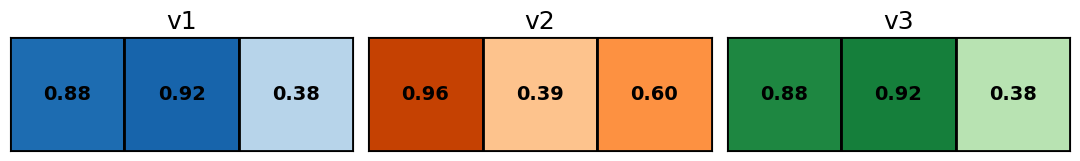

In [8]:
plot_tensors((v1, "v1"), (v2, "v2"), (v3, "v3")) 

---
## 2. Tensor Data Types

| dtype | Description |
|---|---|
| `torch.float32` (default) | 32-bit float |
| `torch.float64` | 64-bit float |
| `torch.float16` | 16-bit float |
| `torch.bfloat16` | Brain float 16 |
| `torch.int32` | 32-bit integer |
| `torch.int64` | 64-bit integer |
| `torch.bool` | Boolean |

### Setting Data Types

You can set the dtype in two ways:
1. **At creation time**: `torch.ones(2, 3, dtype=torch.int16)`
2. **After creation**: using the `.to()` method

**Note**: Converting from float to int truncates (doesn't round). When you print a tensor with non-default dtype, PyTorch includes the dtype in the output.

In [9]:
# Set dtype at creation
a = torch.ones(2, 3, dtype=torch.int16)
print(a)

# Convert with .to()
b = torch.rand(2, 3) * 20
c = b.to(torch.int32)
print(f"float -> int: {b[0].tolist()} -> {c[0].tolist()}")

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)
float -> int: [19.186113357543945, 7.808964252471924, 12.01790714263916] -> [19, 7, 12]


---
## 3. Arithmetic Operations

All standard operators (`+`, `-`, `*`, `/`, `**`) work element-wise on tensors.

**Caution** The `*` operator performs element-wise (Hadamard) multiplication, **not** matrix multiplication. For matrix multiplication, use `@` or `torch.matmul()`.

In [10]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

v_sum = a + b
v_prod = a * b
v_div = a / b
v_power = a ** 2

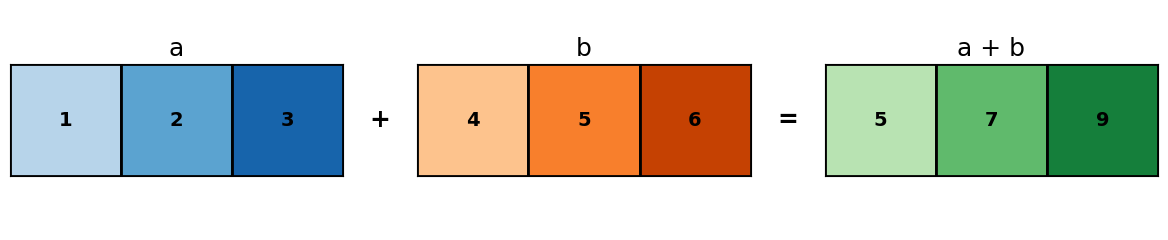

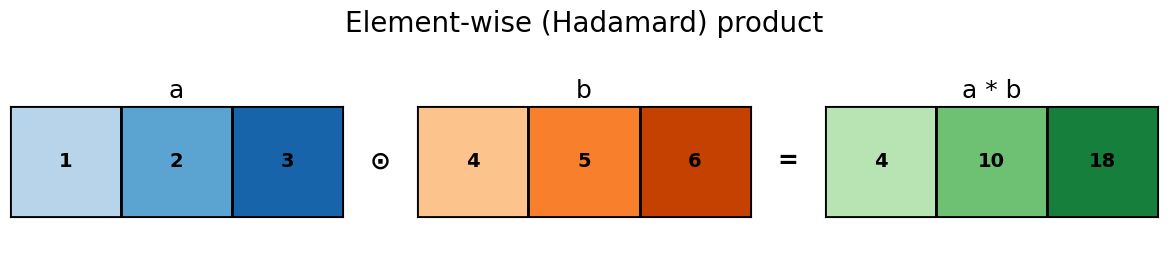

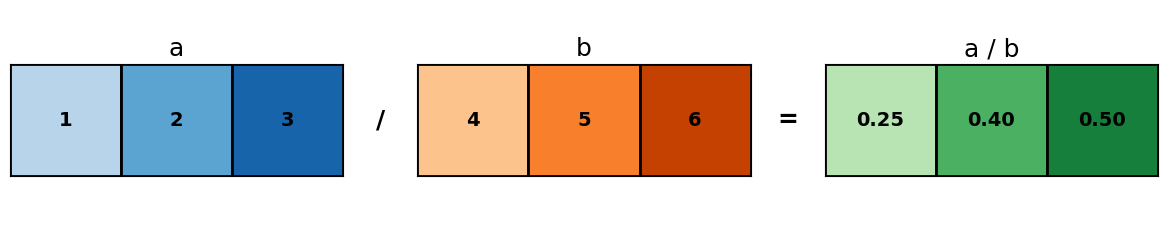

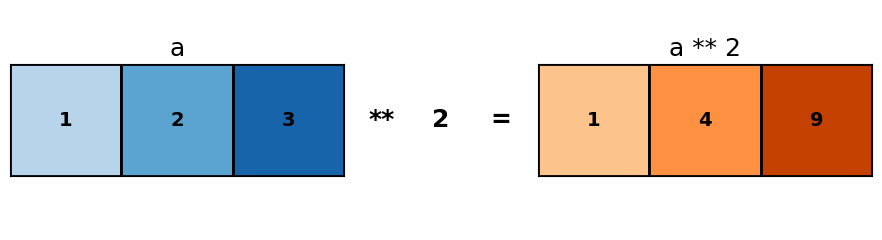

In [11]:
plot_tensors((a, "a"), "+", (b, "b"), "=", (v_sum, "a + b"))
plot_tensors((a, "a"), "\u2299", (b, "b"), "=", (v_prod, "a * b"),
             title="Element-wise (Hadamard) product")
plot_tensors((a, "a"), "/", (b, "b"), "=", (v_div, "a / b"))
plot_tensors((a, "a"), "**", "2", "=", (v_power, "a ** 2"))

### Important: Tensors Must Have Compatible Shapes

When performing arithmetic operations between two tensors, they must either:
1. Have exactly the same shape, or
2. Follow **broadcasting rules** discussed below

Otherwise, you'll get a runtime error. For example, a `(2, 3)` tensor cannot be directly multiplied with a `(3, 2)` tensor without reshaping or transposing.

### In-place operations (trailing `_`)

Methods ending with `_` modify the tensor in place.

**When to use in-place operations:**
- When you no longer need the original tensor and want to save memory
- When you're doing element-wise computations where intermediate values can be discarded

**Caution**: In-place operations can interfere with autograd (automatic differentiation).

In [12]:
x = torch.ones(2, 2)
print("before:", x[0].tolist())

x.add_(3)
print("after add_(3):", x[0].tolist())

x.mul_(2)
print("after mul_(2):", x[0].tolist())

before: [1.0, 1.0]
after add_(3): [4.0, 4.0]
after mul_(2): [8.0, 8.0]


---
## 4. Broadcasting

Broadcasting lets you operate on tensors of different (but compatible) shapes. Rules (checked right-to-left on dimensions):
1. Dimensions must be **equal**, or
2. One of them must be **1** (it gets expanded), or
3. The dimension is **missing** (a size-1 dim is prepended).

### Scalar broadcasting

Operations between tensors and scalars are automatically **broadcast** — the scalar is applied to every element.

In [13]:
# Scalar broadcasting
x = torch.ones(2, 2)
y = x + 5

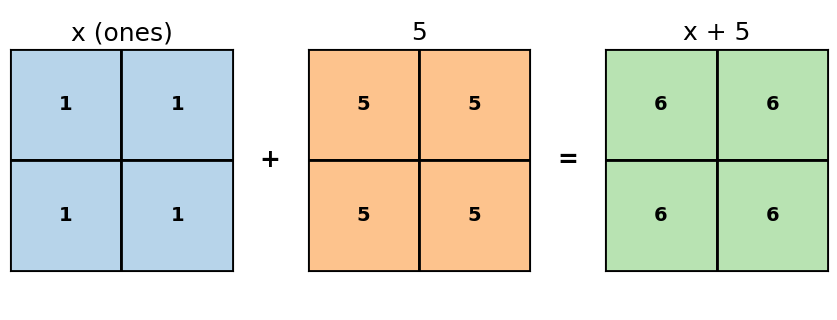

In [14]:
plot_tensors((x, "x (ones)"), "+", (torch.full_like(x, 5), "5"), "=", (x + 5, "x + 5"))

### How Broadcasting Works

When you add a `(3, 1)` tensor to a `(1, 4)` tensor:
1. The column vector is **broadcast** (repeated) horizontally to become `(3, 4)`
2. The row vector is **broadcast** (repeated) vertically to become `(3, 4)`
3. Then element-wise addition produces a `(3, 4)` result

Broadcasting is crucial in data processing — for example, when applying the same operation to each instance in a batch, or when centering data by subtracting means.

In [15]:
# (3,1) + (1,4) -> (3,4)
row = torch.arange(4).reshape(1, 4)        # shape (1, 4)
col = torch.arange(3).reshape(3, 1) * 10   # shape (3, 1)

result = col + row

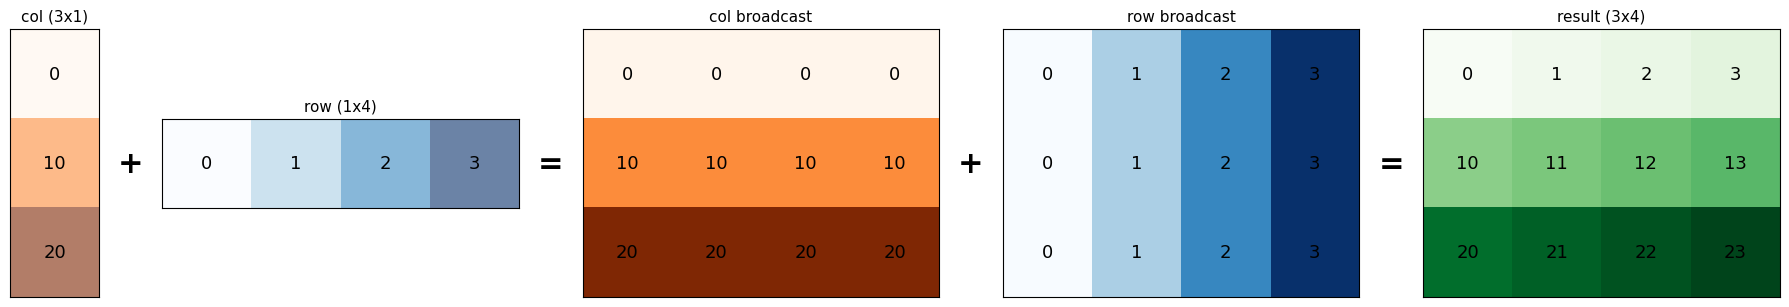

In [16]:
plot_broadcasting(col, row, result)

In [17]:
# Practical example: subtract per-column mean
data = torch.rand(4, 3) * 10
col_mean = data.mean(dim=0)          # shape (3,)
centered = data - col_mean           # broadcasts (3,) -> (4, 3)
new_col_mean = centered.mean(dim=0)

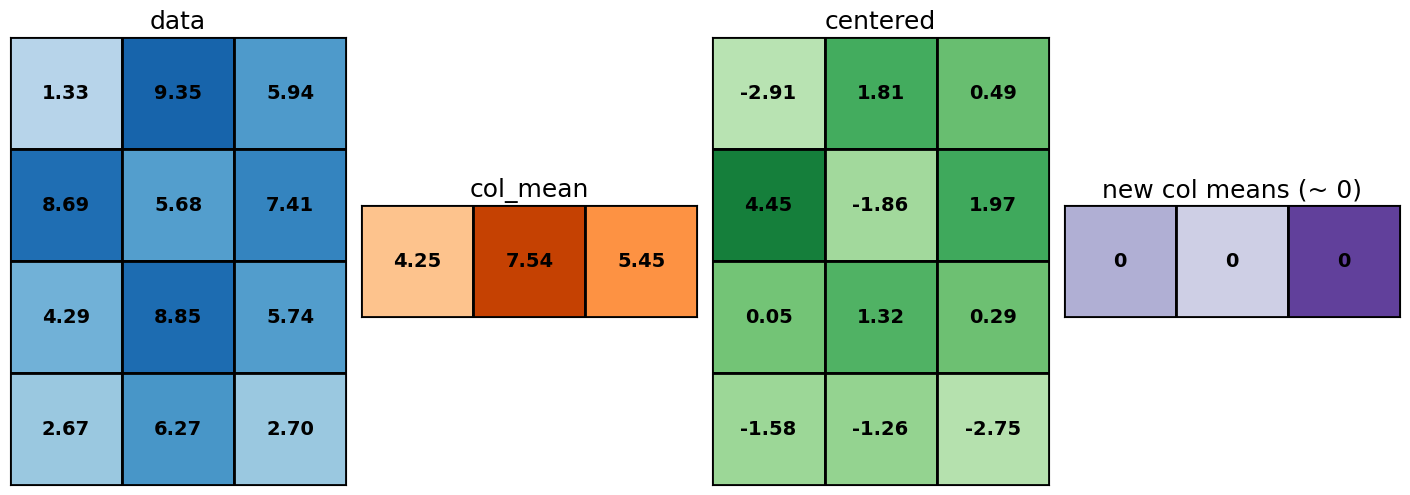

In [18]:
plot_tensors((data, "data"), (col_mean, "col_mean"), (centered, "centered"), (new_col_mean, "new col means (~ 0)"))

---
## 5. Basic Math Functions: min, max, mean, sin, …

PyTorch provides over **1200 operations** on tensors, including:
- **Trigonometric**: `sin`, `cos`, `tan`, `asin`, `acos`, `atan`
- **Statistical**: `mean`, `std`, `var`, `median`, `mode`
- **Comparisons**: `eq`, `ne`, `lt`, `gt`, `le`, `ge`
- **Bitwise**: `bitwise_and`, `bitwise_or`, `bitwise_xor`
- **Linear algebra**: `svd`, `eig`, `qr`, `lstsq`

For the complete list, see the [PyTorch math operations documentation](https://pytorch.org/docs/stable/torch.html#math-operations).

In [19]:
x = torch.tensor([[1.0, 5.0, 3.0],
                   [7.0, 2.0, 9.0]])

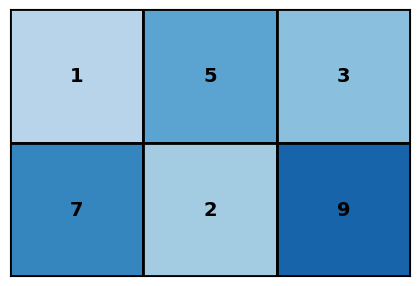

In [20]:
plot_tensors((x,""))

In [21]:
print("min  =", x.min().item())
print("max  =", x.max().item())
print("mean =", x.mean().item())
print("std  =", x.std().item())
print("sum  =", x.sum().item())

min  = 1.0
max  = 9.0
mean = 4.5
std  = 3.082206964492798
sum  = 27.0


### Reduction Operations

Reduction operations collapse a tensor along one or more dimensions:
- Without `dim` argument: reduces to a single scalar
- With `dim=0`: reduces along rows (result has one value per column)
- With `dim=1`: reduces along columns (result has one value per row)

Note that `.max()` with a `dim` argument returns a named tuple with both **values** (the maxima) and **indices** (their positions).

In [22]:
# Reduction along a specific dimension
sum_d1 = x.sum(dim=1) # per-row sum
max_d0 = x.max(dim=0) # per-col max

print("** sum along rows (dim=1):", sum_d1)
print("** max along cols (dim=0):", max_d0)

** sum along rows (dim=1): tensor([ 9., 18.])
** max along cols (dim=0): torch.return_types.max(
values=tensor([7., 5., 9.]),
indices=tensor([1, 0, 1]))


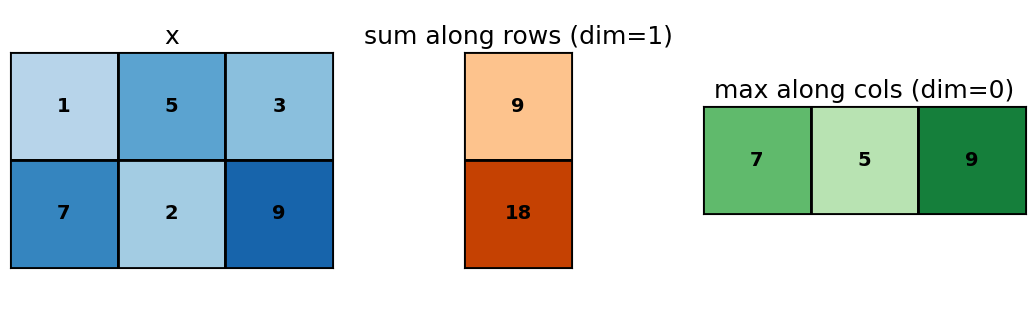

In [23]:
plot_tensors((x, "x"), "", "", (sum_d1.unsqueeze(0).T, "sum along rows (dim=1)"), "", "", (max_d0.values, "max along cols (dim=0)"))

In [24]:
# Other useful element-wise functions
x = torch.tensor([-1.7, -0.3, 0.0, 0.8, 2.5])
print("abs  :", torch.abs(x).tolist())
print("ceil :", torch.ceil(x).tolist())
print("floor:", torch.floor(x).tolist())
print("clamp(-1,1):", torch.clamp(x, -1, 1).tolist())
print("exp  :", torch.exp(x).tolist())
print("sqrt (abs):", torch.sqrt(torch.abs(x)).tolist())

abs  : [1.7000000476837158, 0.30000001192092896, 0.0, 0.800000011920929, 2.5]
ceil : [-1.0, -0.0, 0.0, 1.0, 3.0]
floor: [-2.0, -1.0, 0.0, 0.0, 2.0]
clamp(-1,1): [-1.0, -0.30000001192092896, 0.0, 0.800000011920929, 1.0]
exp  : [0.18268351256847382, 0.740818202495575, 1.0, 2.22554087638855, 12.182494163513184]
sqrt (abs): [1.3038405179977417, 0.547722578048706, 0.0, 0.8944271802902222, 1.5811388492584229]


---
## 6. Vector and Matrix Operations

### Dot product

The `torch.dot` implements a **dot product** of two 1D vectors producing a scalar.

In [25]:
# Dot product
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
print("dot product:", torch.dot(a, b).item())  # 1*4 + 2*5 + 3*6 = 32

dot product: 32.0


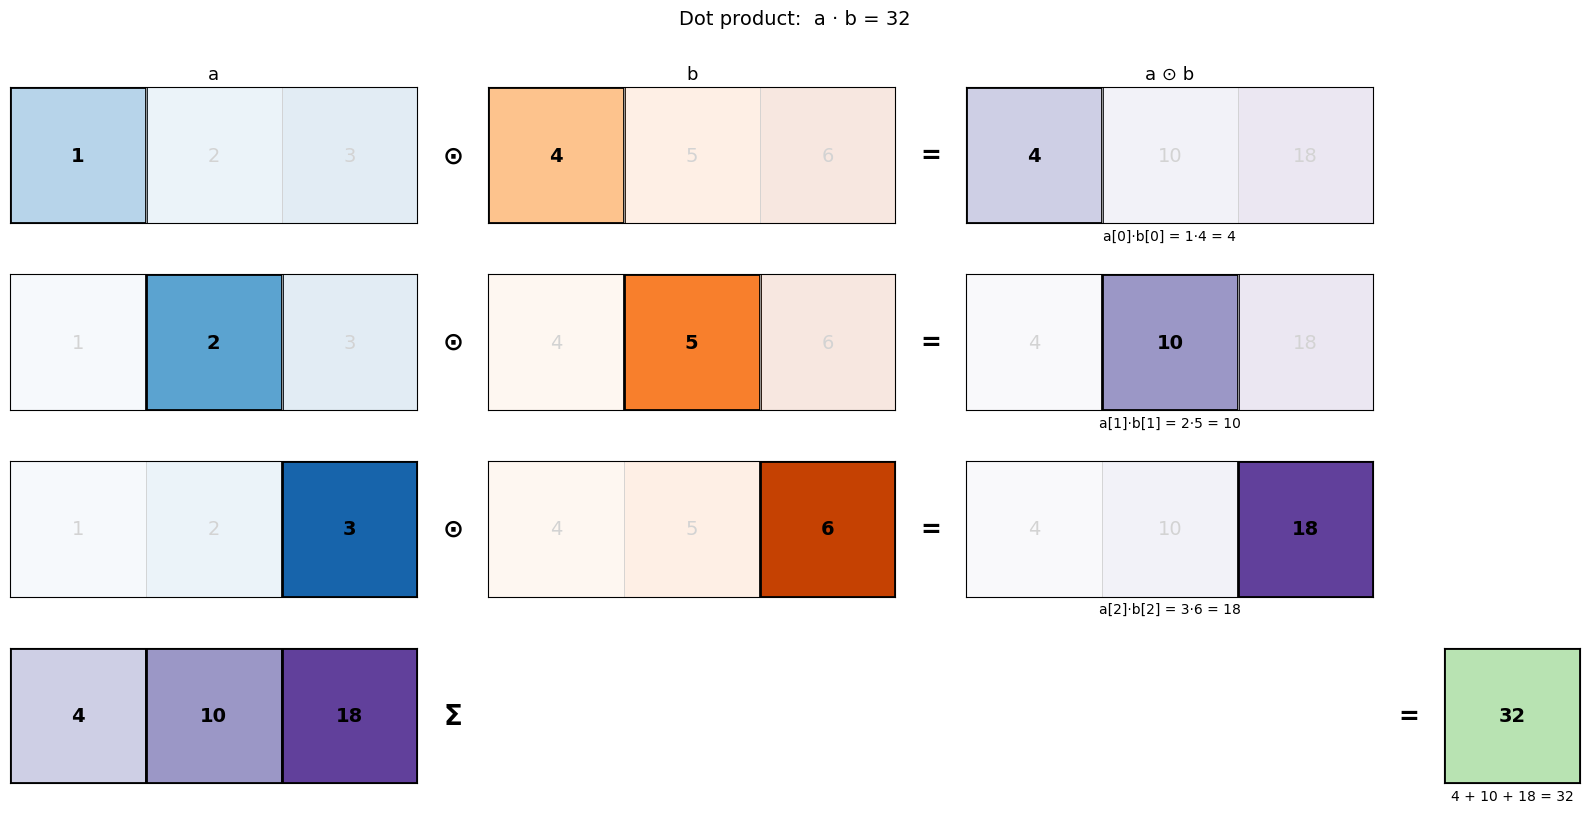

In [26]:
plot_dot_product(a, b)

### Cross product

The `torch.linalg.cross` implements **cross product** for 3D vectors and produces a vector perpendicular to both inputs.

In [27]:
# Cross product (3D vectors)
v1 = torch.tensor([1.0, 0.0, 0.0])
v2 = torch.tensor([0.0, 1.0, 0.0])
print("cross(v1, v2) =", torch.linalg.cross(v1, v2).tolist())  # [0, 0, 1]

cross(v1, v2) = [0.0, 0.0, 1.0]


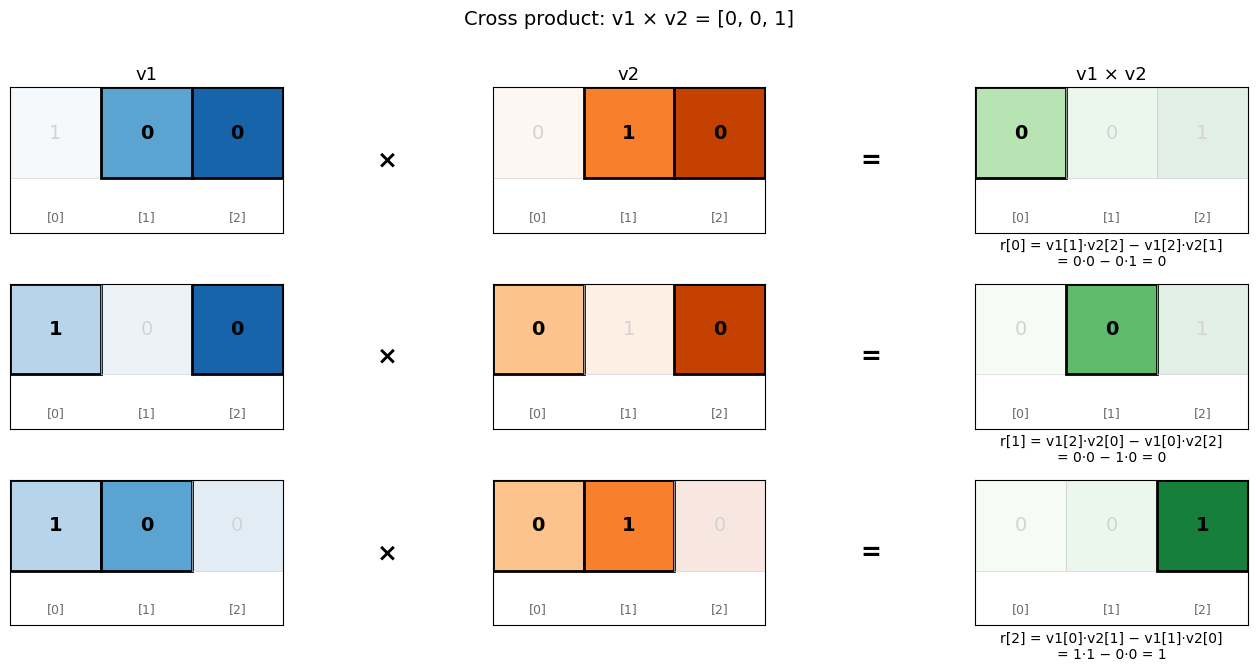

In [28]:
plot_cross_product(v1, v2)

### Matrix Multiplication

For matrix multiplication `C = A @ B`:
- Each element `C[i, j]` is the dot product of row `i` from A and column `j` from B
- Requires: A's number of columns = B's number of rows
- Result shape: `(A.rows, B.cols)`

The `@` operator (or `torch.matmul`) performs matrix multiplication, while `*` does element-wise multiplication.

### Other Matrix operations

- Matrix inversion $A^{-1}$ - `torch.linalg.inv`
- Matrix transposition $A^{T}$ - `.T` attribute of tensor -> `A_transposed = A.T` 

In [29]:
# Matrix multiplication: @ operator or torch.matmul
A = torch.tensor([[1.0, 2.0],
                   [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0],
                   [7.0, 8.0]])

print("A @ B =")
print(A @ B)

# Transpose
print("\nA^T =")
print(A.T)

A @ B =
tensor([[19., 22.],
        [43., 50.]])

A^T =
tensor([[1., 3.],
        [2., 4.]])


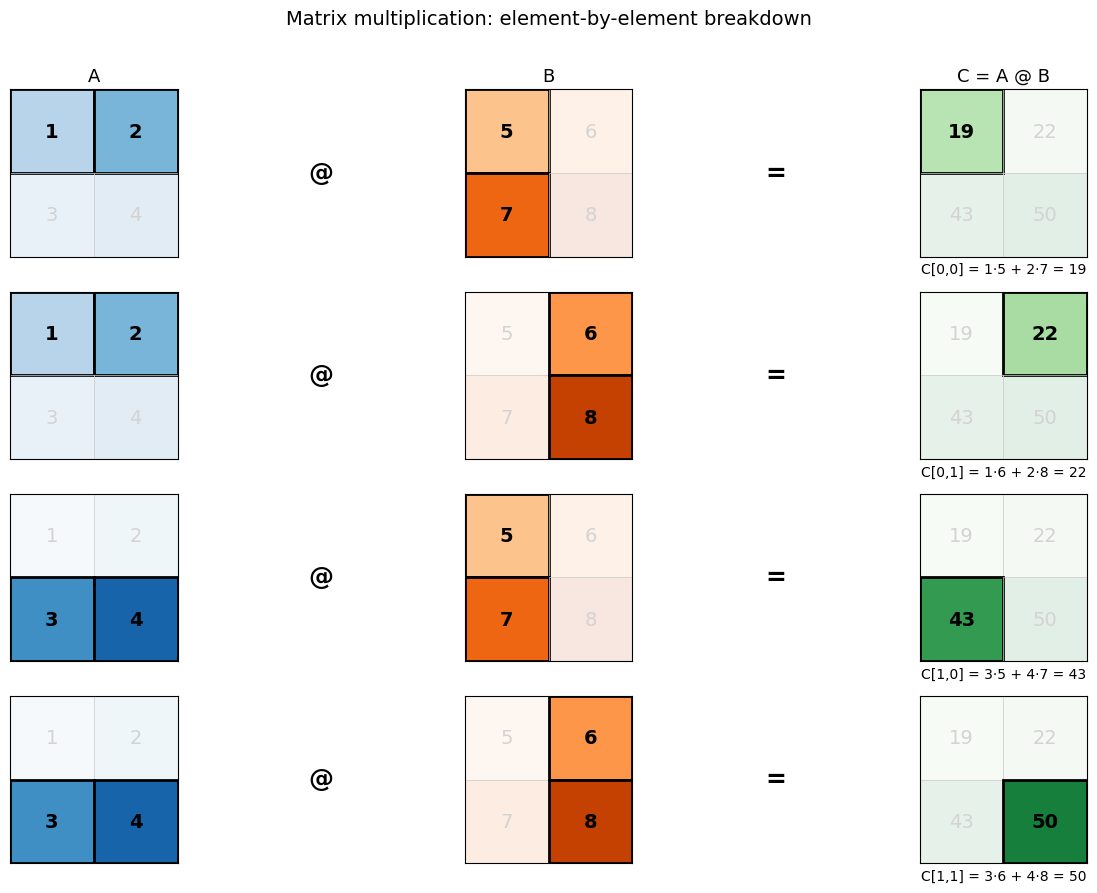

In [30]:
plot_matmul(A, B)

---
## 7. Changing Tensor Shapes

| Method | Purpose |
|---|---|
| `reshape(new_shape)` | Change shape (same number of elements) |
| `unsqueeze(dim)` | Add a size-1 dimension |
| `squeeze(dim)` | Remove a size-1 dimension |
| `ravel()` / `flatten()` | Flatten to 1-D |
| `permute(dims)` | Reorder dimensions |
| `view(shape)` | Like reshape, always returns a view |

In [31]:
x = torch.arange(12)
print("original:", x.shape)

a = x.reshape(3, 4)
print("reshape(3,4):", a.shape)

b = a.unsqueeze(0)       # add batch dim
print("unsqueeze(0):", b.shape)

c = b.squeeze(0)         # remove it
print("squeeze(0):  ", c.shape)

d = a.ravel()            # flatten
print("ravel():     ", d.shape)

print("\nravel == flatten:", torch.equal(a.ravel(), a.flatten()))

original: torch.Size([12])
reshape(3,4): torch.Size([3, 4])
unsqueeze(0): torch.Size([1, 3, 4])
squeeze(0):   torch.Size([3, 4])
ravel():      torch.Size([12])

ravel == flatten: True


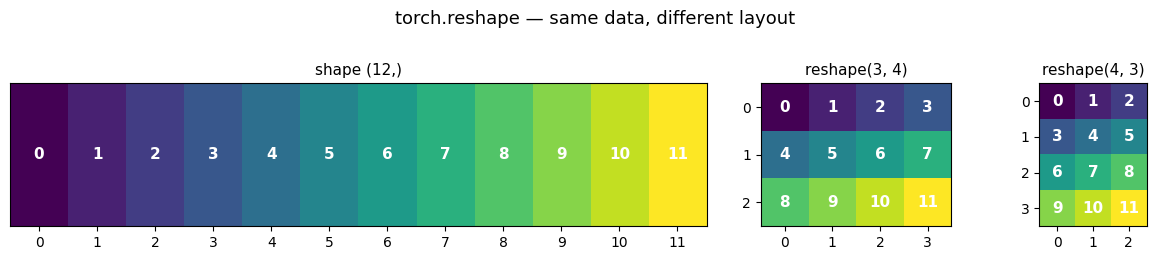

In [32]:
plot_reshape(torch.arange(12))

### Views vs Copies

When you `reshape()` a tensor, PyTorch tries to return a **view** — a different way of looking at the same underlying memory. This means:
- ✅ **Fast**: no data copying
- ⚠️ **Shared memory**: changes to the view affect the original

If you need an independent copy, use `.clone()` first:
```python
independent = x.clone().reshape(new_shape)
```

The visualization above shows how the **same data** can be interpreted as different shapes — the memory layout remains unchanged, only the indexing changes.

In [33]:
# squeeze / unsqueeze — common in deep learning (adding/removing batch dim)
img = torch.rand(3, 224, 224)        # single image: C x H x W
batch = img.unsqueeze(0)             # batch of 1:   1 x C x H x W
print(f"image: {img.shape}  ->  batch: {batch.shape}")

output = torch.rand(1, 10)           # model output for batch of 1
vector = output.squeeze(0)           # remove batch dim
print(f"output: {output.shape}  ->  vector: {vector.shape}")

image: torch.Size([3, 224, 224])  ->  batch: torch.Size([1, 3, 224, 224])
output: torch.Size([1, 10])  ->  vector: torch.Size([10])


## 8. Exercise 1: Weather Station

[Weather Station Notebook](Exc_1_Weather_Station.ipynb)

---
## 9. NumPy Conversion

PyTorch and NumPy can share memory — changes to one are reflected in the other.

In [34]:
# NumPy -> Tensor (shared memory!)
np_arr = np.array([[1.0, 2.0], [3.0, 4.0]])
t = torch.from_numpy(np_arr)
print("tensor:", t)

np_arr[0, 0] = 99
print("after modifying numpy, tensor:", t)  # also changed!

tensor: tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
after modifying numpy, tensor: tensor([[99.,  2.],
        [ 3.,  4.]], dtype=torch.float64)


In [35]:
# Tensor -> NumPy (shared memory!)
t2 = torch.rand(2, 3)
np2 = t2.numpy()
print("numpy array:", np2)

t2[0, 0] = -1
print("after modifying tensor, numpy:", np2)  # also changed!

numpy array: [[0.6001786  0.03513288 0.682584  ]
 [0.37432557 0.5220172  0.13360566]]
after modifying tensor, numpy: [[-1.          0.03513288  0.682584  ]
 [ 0.37432557  0.5220172   0.13360566]]


### Important: Shared Memory with NumPy

By default, `torch.from_numpy()` and `.numpy()` **share the same underlying memory**. This means:
- ✅ **Fast**: no data copying
- ⚠️ **Changes propagate**: modifying one affects the other

If you need independent copies:
- From NumPy: `torch.from_numpy(arr).clone()`
- To NumPy: `tensor.clone().numpy()` or `tensor.detach().numpy()` (if tensor has gradients)

This tight integration makes it easy to use PyTorch alongside existing NumPy-based code and libraries like scikit-learn.

In [36]:
# Use .clone() to avoid shared memory
safe_tensor = torch.from_numpy(np.array([1, 2, 3])).clone()
# now they are independent

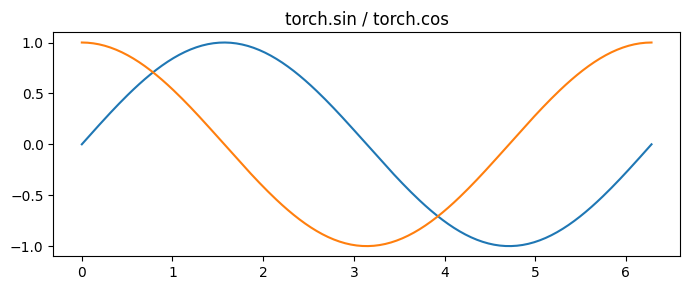

In [37]:
"""Plot sin and cos curves over [0, 2*pi]."""
t = torch.linspace(0, 2 * math.pi, 200)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t, torch.sin(t), label="sin")
ax.plot(t.numpy(), torch.cos(t).numpy(), label="cos")

ax.set_title("torch.sin / torch.cos")
plt.tight_layout()
plt.show()

---
## 10. Indexing and Slicing

PyTorch indexing follows NumPy conventions.

In [38]:
x = torch.arange(20).reshape(4, 5)
print("x ="); print(x)

print("\nx[0]       =", x[0].tolist())           # first row
print("x[-1]      =", x[-1].tolist())             # last row
print("x[:, 2]    =", x[:, 2].tolist())           # third column
print("x[1:3, 1:4]=", x[1:3, 1:4].tolist())      # sub-matrix
print("x[::2]     =", x[::2].tolist())            # every other row

x =
tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])

x[0]       = [0, 1, 2, 3, 4]
x[-1]      = [15, 16, 17, 18, 19]
x[:, 2]    = [2, 7, 12, 17]
x[1:3, 1:4]= [[6, 7, 8], [11, 12, 13]]
x[::2]     = [[0, 1, 2, 3, 4], [10, 11, 12, 13, 14]]


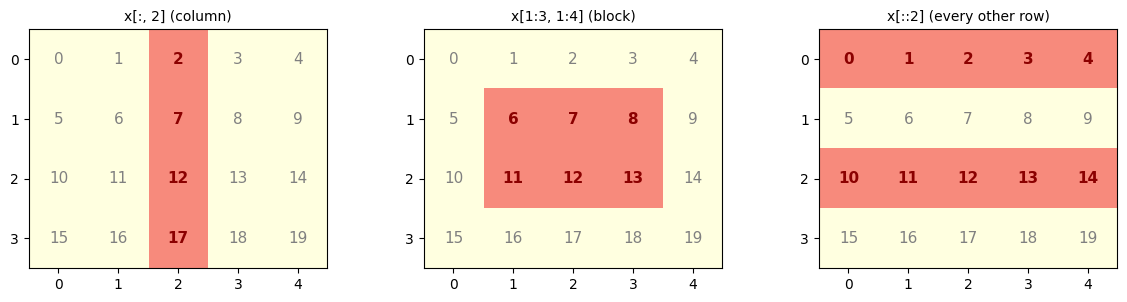

In [39]:
plot_slicing(x)

---
## 11. Boolean Masks

Comparison operators (`>`, `<`, `==`, `>=`, `<=`, `!=`) return **boolean tensors** with the same shape as the input. These masks can be used to:
1. **Select elements**: `x[mask]` returns a 1D tensor of selected values
2. **Modify elements**: `x[mask] = new_value` changes selected elements
3. **Conditional operations**: `torch.where(mask, x, y)` chooses from two tensors

Boolean masks are essential for:
- Data filtering and cleaning
- Application of step functions (e.g., Sigmoid)
- Handling missing values

In [40]:
torch.manual_seed(0)
x = torch.randint(-5, 10, (4, 5))

mask = x > 3

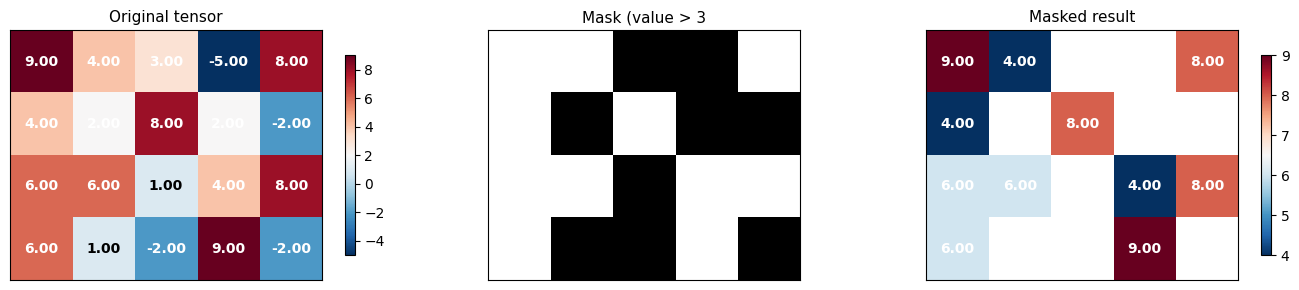

In [41]:
plot_masking(x, mask, "Mask (value > 3")

In [42]:
# Modify elements via mask
y = x.clone()
y[y < 0] = 0

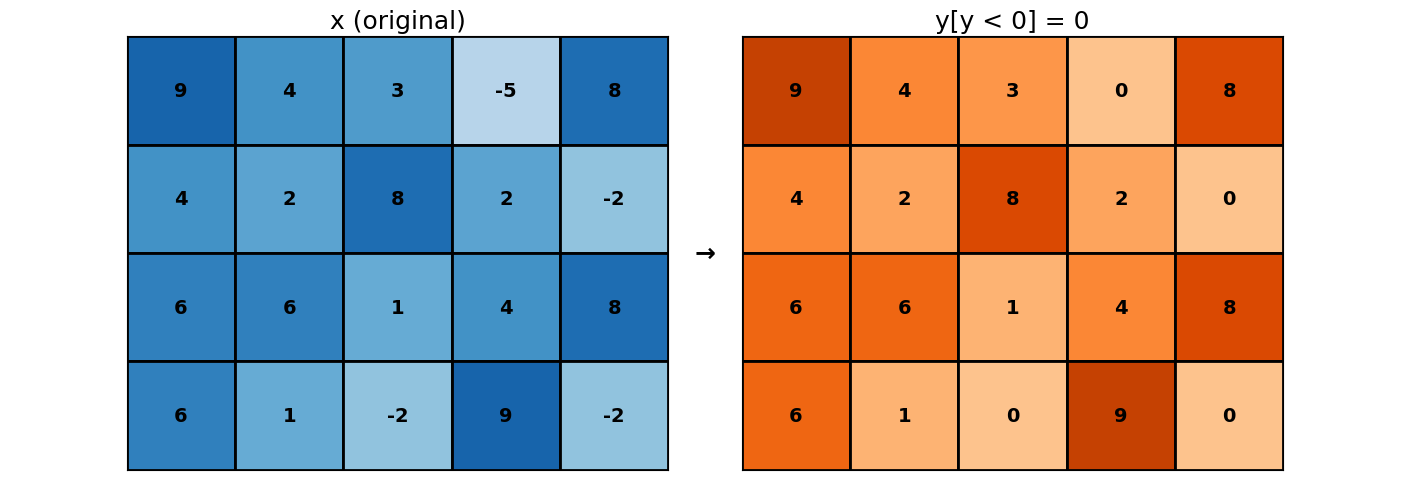

In [43]:
plot_tensors("", "", (x, "x (original)"), "\u2192", (y, "y[y < 0] = 0"), "", "")

In [44]:
# torch.where: choose from two tensors based on condition
pos = torch.ones_like(x)
neg = torch.zeros_like(x)
result = torch.where(x > 0, pos, neg)

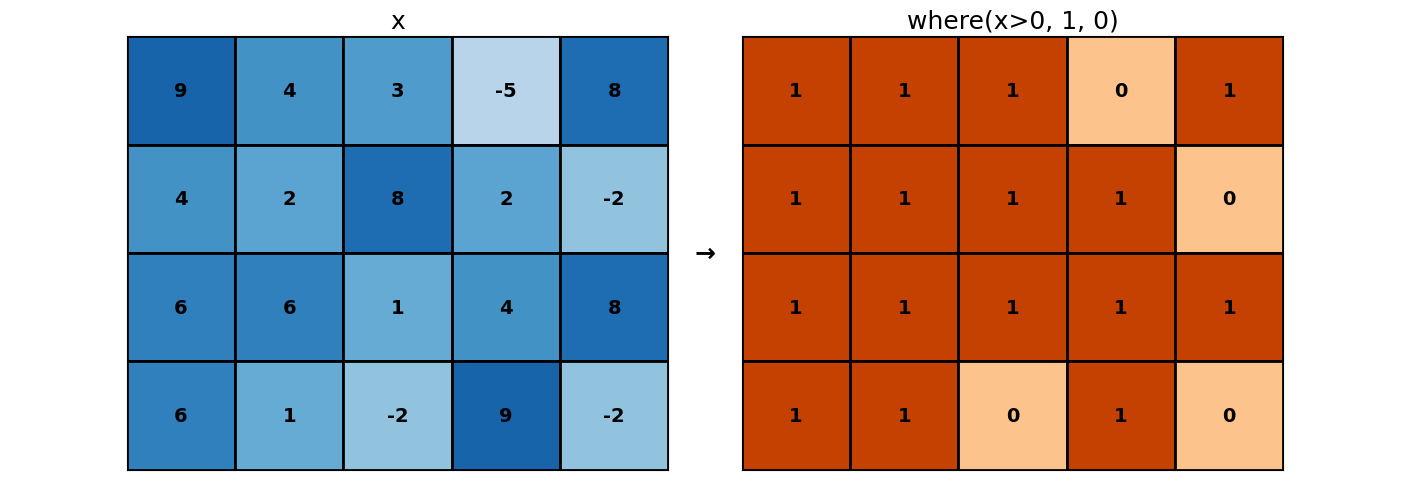

In [45]:
plot_tensors("", "", (x, "x"), "\u2192", (result, "where(x>0, 1, 0)"), "", "")

In [46]:
torch.manual_seed(7)
data = torch.randn(6, 8)
mask = data > 0.5

# Masked result
masked = torch.where(mask, data, torch.tensor(float("nan")))

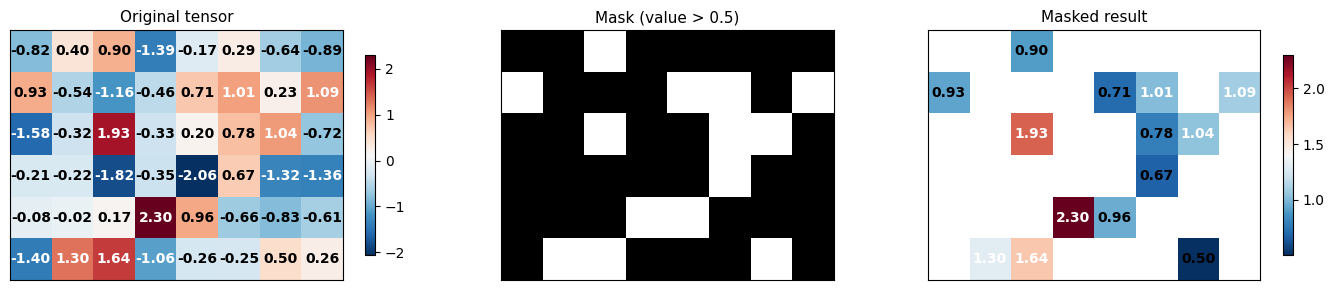

In [47]:
plot_masking(data, mask, "Mask (value > 0.5)")

### Combining Masks with Logical Operators

You can combine boolean masks using:
- `&` — AND (both conditions must be True)
- `|` — OR (at least one condition must be True)
- `~` — NOT (inverts True/False)

**Important**: Use `&`, `|`, `~` for element-wise operations on boolean tensors, not Python's `and`, `or`, `not` keywords. Always use parentheses around each condition when combining masks:
```python
mask = (x >= 5) & (x <= 14)  # ✅ Correct
mask = x >= 5 & x <= 14      # ❌ Wrong (operator precedence issue)
```

In [48]:
# Combining masks with logical operators
x = torch.arange(20).reshape(4, 5).float()

mask_combined = (x >= 5) & (x <= 14)

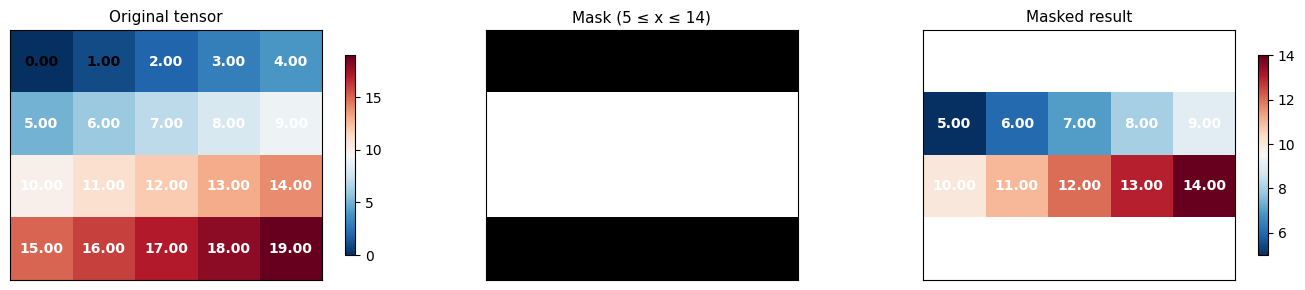

In [49]:
plot_masking(x, mask_combined, "Mask (5 \u2264 x \u2264 14)")

## 12. Excercise 2: Student Grades

[Student Grades Notebook](Exc_2_Student_Grades.ipynb)

---
## Summary

| Topic | Key functions |
|---|---|
| **Creation** | `tensor()`, `zeros()`, `ones()`, `rand()`, `arange()`, `linspace()` |
| **Data types** | `dtype=torch.float32`, `.to(dtype)` |
| **Arithmetic** | `+`, `-`, `*`, `/`, `**`, in-place: `add_()`, `mul_()` |
| **Math** | `sin`, `cos`, `exp`, `abs`, `clamp`, `min`, `max`, `mean`, `std` |
| **Linear algebra** | `@` / `matmul`, `dot`, `cross`, `.T` |
| **Broadcasting** | Automatic shape expansion following NumPy rules |
| **Indexing** | `x[i]`, `x[i:j]`, `x[:, k]`, `x[::step]` |
| **Shapes** | `reshape`, `squeeze`, `unsqueeze`, `ravel`, `flatten`, `permute` |
| **NumPy** | `from_numpy()`, `.numpy()` (shared memory!) |
| **Masking** | Boolean indexing, `torch.where()`, `&`, `\|`, `~` |